# 🎤 INSTRUCTOR — Concepts notebook (screen-share this one)
Blockquotes are **your notes** (not in the student copy). Suggested pacing for ~100 min *(adjust to your slot)*:

| Min | Part | Key idea |
|---|---|---|
| 0–15 | 1 · Probability concepts | long-run frequency, sample space, events, rules |
| 15–30 | 2 · Conditional probability | "probability *given*"; P(A\|B) ≠ P(B\|A) |
| 30–42 | 3 · Independence | P(A∩B)=P(A)P(B); exclusive ≠ independent |
| 42–62 | 4 · **Bayes' theorem** | the base-rate trap — the climax |
| 62–72 | ☕ Break | |
| 72–85 | 5 · Random variables | pmf, E[X], Var(X) |
| 85–100 | 6 · Distributions | Binomial, Poisson, Normal, CLT |

**Rhythm:** every part has a 🔮 PREDICT box → students type guesses in chat *before* you run the cell.
**Next notebooks:** `02_INSTRUCTOR_ai_demo` (you teach the AI workflow) and `03_STUDENT_ai_tasks` (they practise).

In [2]:
#@title ▶️ Setup — run this cell first { display-mode: "form" }
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(42)     # fixed seed → everyone sees the same random numbers
print("✅ Setup complete")

✅ Setup complete


---
## Part 1 · Probability concepts

**Probability** = a number between 0 and 1 for how likely an event is. Two ways to think about it:
* **Classical:** (favourable outcomes) ÷ (all equally likely outcomes)
* **Frequentist:** the proportion of times it happens in the *long run*

| Rule | Formula |
|---|---|
| Complement | $P(\text{not }A) = 1 - P(A)$ |
| Addition | $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ |

### 🔮 PREDICT (answer in chat *before* running the next cell)


I flip a fair coin 10 times. Will the proportion of heads be *exactly* 0.5? And after 5,000 flips?
**Chat:** "10 flips: ___ , 5000 flips: ___" (always / often / rarely exactly 0.5)

> 🎤 The honest answer: even at 5000 flips it's almost never *exactly* 0.5, but it gets very **close**. That is the Law of Large Numbers.

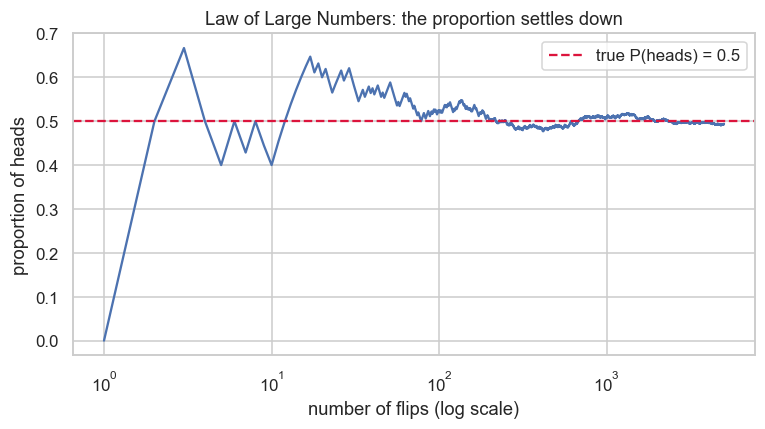

after 10 flips  : 0.4
after 5000 flips: 0.494


In [7]:
flips = rng.integers(0, 2, size=5000)                  # 1 = heads
running = np.cumsum(flips) / np.arange(1, 5001)        # proportion of heads so far

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(np.arange(1, 5001), running, lw=1.5)
ax.axhline(0.5, color="crimson", ls="--", label="true P(heads) = 0.5")
ax.set_xscale("log"); ax.set_xlabel("number of flips (log scale)"); ax.set_ylabel("proportion of heads")
ax.set_title("Law of Large Numbers: the proportion settles down"); ax.legend()
plt.show()
print("after 10 flips  :", running[9].round(3))
print("after 5000 flips:", running[-1].round(4))

> 🎤 SAY: "Short runs are wild; long runs are calm. A *probability* is what the proportion converges to. It says nothing certain about the next flip."
> ⚠️ Gambler's fallacy: a coin that landed heads 5 times is *not* "due" for tails.

### Sample space: two dice

number of equally likely outcomes: 36


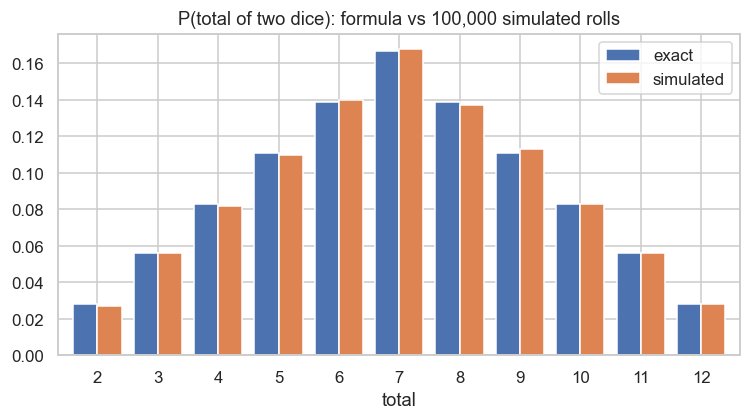

,2,3,4,5,6,7,8,9,10,11,12
exact,0.028,0.056,0.083,0.111,0.139,0.167,0.139,0.111,0.083,0.056,0.028
simulated,0.027,0.056,0.082,0.110,0.140,0.168,0.137,0.113,0.083,0.056,0.028


In [10]:
die = np.arange(1, 7)
outcomes = pd.DataFrame([(a, b, a + b) for a in die for b in die], columns=["die1", "die2", "total"])
print("number of equally likely outcomes:", len(outcomes))

exact = outcomes["total"].value_counts(normalize=True).sort_index()
sim_totals = rng.integers(1, 7, 100_000) + rng.integers(1, 7, 100_000)
simulated = pd.Series(sim_totals).value_counts(normalize=True).sort_index()
table = pd.DataFrame({"exact": exact, "simulated": simulated}).round(3)

ax = table.plot.bar(figsize=(8, 3.8), rot=0, width=0.8)
ax.set_title("P(total of two dice): formula vs 100,000 simulated rolls"); ax.set_xlabel("total")
plt.show()
table.T

### Addition rule: 'A or B'

In [12]:
A_ = outcomes["die1"] == 6          # event A: first die is 6
B_ = outcomes["total"] >= 10        # event B: total is 10 or more
pA, pB, pAB = A_.mean(), B_.mean(), (A_ & B_).mean()
print(f"P(A) = {pA:.3f}   P(B) = {pB:.3f}   P(A and B) = {pAB:.3f}")
print(f"P(A or B) = P(A)+P(B)-P(A and B) = {pA + pB - pAB:.3f}")
print(f"counted directly            = {(A_ | B_).mean():.3f}")

P(A) = 0.167   P(B) = 0.167   P(A and B) = 0.083
P(A or B) = P(A)+P(B)-P(A and B) = 0.250
counted directly            = 0.250


> 🎤 SAY: "Why subtract P(A and B)? Because the outcomes (6,4), (6,5), (6,6) are in *both* events — adding would count them twice."

---
## Part 2 · Conditional probability
**P(A | B)** = probability of A *given that we know B happened* — we shrink the world to only the B cases.

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)}$$

In [16]:
# 400 students: did they join a study group, and did they pass?
students = pd.DataFrame({
    "study_group": ["Yes"] * 150 + ["No"] * 250,
    "result": ["Pass"] * 120 + ["Fail"] * 30 + ["Pass"] * 150 + ["Fail"] * 100,
})
counts = pd.crosstab(students["study_group"], students["result"], margins=True)
display(counts)
display(pd.crosstab(students["study_group"], students["result"], normalize="all").round(3))

result,Fail,Pass,All
study_group,,,
No,100,150,250
Yes,30,120,150
All,130,270,400


result,Fail,Pass
study_group,,
No,0.250,0.375
Yes,0.075,0.300


### 🔮 PREDICT (answer in chat *before* running the next cell)


From the table: P(pass) overall is 270/400 = 0.675.

**Chat:** is P(pass | joined a study group) **higher, lower, or the same**? Roughly what number?

> 🎤 Expect 'higher'. Compute: 120/150 = 0.80.

In [19]:
p_pass = (students["result"] == "Pass").mean()
p_pass_given_group = (students[students["study_group"] == "Yes"]["result"] == "Pass").mean()
p_pass_given_none = (students[students["study_group"] == "No"]["result"] == "Pass").mean()
p_group_given_pass = (students[students["result"] == "Pass"]["study_group"] == "Yes").mean()

print(f"P(pass)                  = {p_pass:.3f}")
print(f"P(pass | study group)    = {p_pass_given_group:.3f}")
print(f"P(pass | no study group) = {p_pass_given_none:.3f}")
print(f"P(study group | pass)    = {p_group_given_pass:.3f}   ← NOT the same as P(pass | study group)!")

P(pass)                  = 0.675
P(pass | study group)    = 0.800
P(pass | no study group) = 0.600
P(study group | pass)    = 0.444   ← NOT the same as P(pass | study group)!


> 🎤 SAY: "Look at the last two lines. 80% of study-group students pass. But only 44% of *passing* students were in a study group. **P(A|B) is not P(B|A).** Confusing these is the single most common probability mistake — and it's exactly what trips people up in Bayes later."
> (This is *association*, not proof that study groups cause passing — callback to Class 03.)

### Same idea with dice

In [22]:
cond = outcomes[outcomes["die1"] % 2 == 0]               # shrink the world: first die is even
print("P(total = 8)                 =", round((outcomes["total"] == 8).mean(), 4), "  (= 5/36)")
print("P(total = 8 | first die even) =", round((cond["total"] == 8).mean(), 4), "  (= 3/18)")

P(total = 8)                 = 0.1389   (= 5/36)
P(total = 8 | first die even) = 0.1667   (= 3/18)


**Multiplication rule** (rearranged): $P(A\cap B)=P(A\mid B)\,P(B)$ — used for chains of events, e.g. drawing cards one after another.

---
## Part 3 · Independence
**A and B are independent** if knowing B doesn't change the probability of A: $P(A\cap B)=P(A)\,P(B)$ (equivalently $P(A\mid B)=P(A)$).

In [25]:
def check_independence(A, B, label):
    pA, pB, pAB = A.mean(), B.mean(), (A & B).mean()
    verdict = "INDEPENDENT ✅" if np.isclose(pAB, pA * pB) else "DEPENDENT ❌"
    print(f"{label}\n   P(A)={pA:.3f}  P(B)={pB:.3f}  P(A)P(B)={pA*pB:.3f}  P(A and B)={pAB:.3f}  →  {verdict}\n")

check_independence(outcomes["die1"] % 2 == 0, outcomes["total"] == 7,
                   "A: first die even   B: total is 7")
check_independence(outcomes["die1"] == 6, outcomes["total"] >= 10,
                   "A: first die is 6   B: total ≥ 10")
check_independence(outcomes["die1"] == 1, outcomes["die1"] == 6,
                   "A: first die is 1   B: first die is 6  (mutually exclusive)")

A: first die even   B: total is 7
   P(A)=0.500  P(B)=0.167  P(A)P(B)=0.083  P(A and B)=0.083  →  INDEPENDENT ✅

A: first die is 6   B: total ≥ 10
   P(A)=0.167  P(B)=0.167  P(A)P(B)=0.028  P(A and B)=0.083  →  DEPENDENT ❌

A: first die is 1   B: first die is 6  (mutually exclusive)
   P(A)=0.167  P(B)=0.167  P(A)P(B)=0.028  P(A and B)=0.000  →  DEPENDENT ❌



### 🔮 PREDICT (answer in chat *before* running the next cell)


Before the output above: do you think **'first die is even'** and **'total is 7'** are independent?

> 🎤 Most say 'no'. The check says yes: whatever the first die shows, exactly one second-die value makes 7, so P(7) = 1/6 regardless.

> 🎤 SAY: "**Mutually exclusive is NOT independent.** If A happens, B *can't* — so knowing A tells you a lot about B. Exclusive events with positive probability are always dependent."

### Cards: with vs without replacement

In [30]:
p_ace = 4 / 52
print("P(2nd card is ace | 1st was ace), WITH replacement    :", round(4 / 52, 4), "(same as P(ace) → independent)")
print("P(2nd card is ace | 1st was ace), WITHOUT replacement :", round(3 / 51, 4), "(deck changed → dependent)")

deck = np.array([1] * 4 + [0] * 48)                      # 1 = ace
draws = np.array([rng.permutation(deck)[:2] for _ in range(100_000)])
first_ace = draws[:, 0] == 1
print("simulated, without replacement:", round(draws[first_ace, 1].mean(), 4))

P(2nd card is ace | 1st was ace), WITH replacement    : 0.0769 (same as P(ace) → independent)
P(2nd card is ace | 1st was ace), WITHOUT replacement : 0.0588 (deck changed → dependent)
simulated, without replacement: 0.055


---
## Part 4 · Bayes' theorem — updating beliefs with evidence

$$P(H\mid E)=\frac{P(E\mid H)\,P(H)}{P(E)} \qquad P(E)=P(E\mid H)P(H)+P(E\mid \neg H)P(\neg H)$$

*prior* $P(H)$ → see evidence $E$ → *posterior* $P(H\mid E)$

### 🩺 The medical test puzzle
A disease affects **1 %** of people. A test is **95 % sensitive** (positive for 95 % of sick people) and has a **5 % false-positive rate** (positive for 5 % of healthy people).
**You test positive.** What's the probability you actually have the disease?

### 🔮 PREDICT (answer in chat *before* running the next cell)

**Gut answer in chat — don't calculate!** A) ~95 % &nbsp; B) ~80 % &nbsp; C) ~50 % &nbsp; D) ~16 % &nbsp; E) ~5 %

> 🎤 Most say 95%. Many doctors do too. Collect the votes and keep them visible.

In [36]:
prevalence, sensitivity, false_pos = 0.01, 0.95, 0.05

p_positive = sensitivity * prevalence + false_pos * (1 - prevalence)
posterior = sensitivity * prevalence / p_positive
print(f"P(positive test)           = {p_positive:.4f}")
print(f"P(disease | positive test) = {posterior:.3f}   ← about {posterior:.0%}")

P(positive test)           = 0.0590
P(disease | positive test) = 0.161   ← about 16%


### Why? Think in *natural frequencies*: 10,000 people

sick: 100  → 95 test positive, 5 test negative
healthy: 9900 → 495 test positive (FALSE alarms), 9405 test negative

Among all 590 positive tests, only 95 are truly sick  →  16.1%


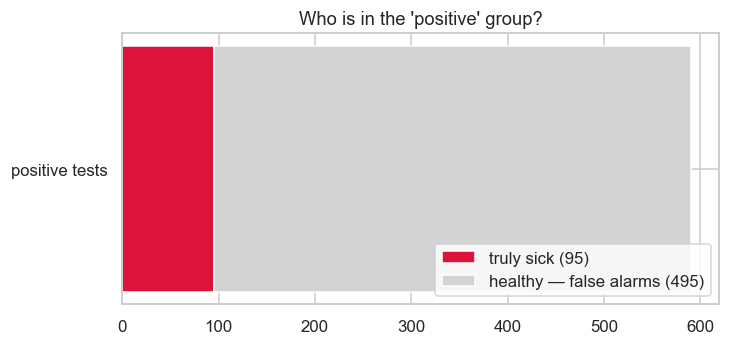

In [38]:
N = 10_000
sick = int(N * prevalence)
healthy = N - sick
tp = round(sick * sensitivity)           # sick & positive
fp = round(healthy * false_pos)          # healthy & positive
print(f"sick: {sick}  → {tp} test positive, {sick - tp} test negative")
print(f"healthy: {healthy} → {fp} test positive (FALSE alarms), {healthy - fp} test negative")
print(f"\nAmong all {tp + fp} positive tests, only {tp} are truly sick  →  {tp / (tp + fp):.1%}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(["positive tests"], [tp], color="crimson", label=f"truly sick ({tp})")
ax.barh(["positive tests"], [fp], left=[tp], color="lightgray", label=f"healthy — false alarms ({fp})")
ax.set_title("Who is in the 'positive' group?"); ax.legend(loc="lower right")
plt.show()

> 🎤 SAY: "The healthy group is **99 times bigger**, so even a small 5% false-positive rate produces ~495 false alarms — far more than the 95 true positives. **Ignoring the base rate (prior) is the #1 Bayes mistake.**"
> 🎤 Reveal the poll: "If you said 95%, you're in excellent company."

### Check it by simulation (1,000,000 people)

In [41]:
n = 1_000_000
is_sick = rng.random(n) < prevalence
test_pos = np.where(is_sick, rng.random(n) < sensitivity, rng.random(n) < false_pos)
print("simulated P(disease | positive) =", round(is_sick[test_pos].mean(), 3))

simulated P(disease | positive) = 0.161


### How much does the prior matter?

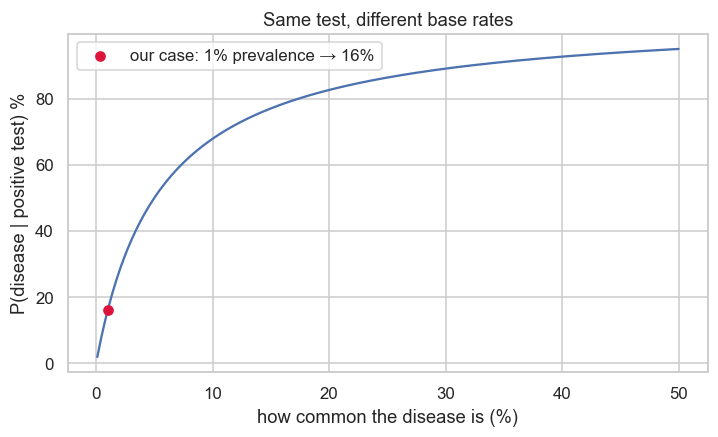

In [43]:
prev = np.linspace(0.001, 0.5, 300)
post = sensitivity * prev / (sensitivity * prev + false_pos * (1 - prev))
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(prev * 100, post * 100)
ax.scatter([1], [posterior * 100], color="crimson", zorder=3, label="our case: 1% prevalence → 16%")
ax.set_xlabel("how common the disease is (%)"); ax.set_ylabel("P(disease | positive test) %")
ax.set_title("Same test, different base rates"); ax.legend()
plt.show()

### Updating again: a second independent positive test

In [45]:
prior_2 = posterior                         # yesterday's posterior is today's prior
post_2 = sensitivity * prior_2 / (sensitivity * prior_2 + false_pos * (1 - prior_2))
print(f"after 1 positive test : {posterior:.1%}")
print(f"after 2 positive tests: {post_2:.1%}")

after 1 positive test : 16.1%
after 2 positive tests: 78.5%


> 🎤 SAY: "**Bayes = a machine for updating.** Each new piece of evidence turns the old posterior into the new prior. This is how spam filters, medical diagnosis and many ML models work. *(Spam filters are one of the tasks in the student AI homework.)*"
> ☕ Break after this part.

---
## ☕ Break

---
## Part 5 · Random variables
A **random variable** $X$ turns outcomes into numbers (e.g. *total of two dice*). A **pmf** lists $P(X=x)$ for each value.

E[X]   = 7.00
Var(X) = 5.833    SD = 2.415


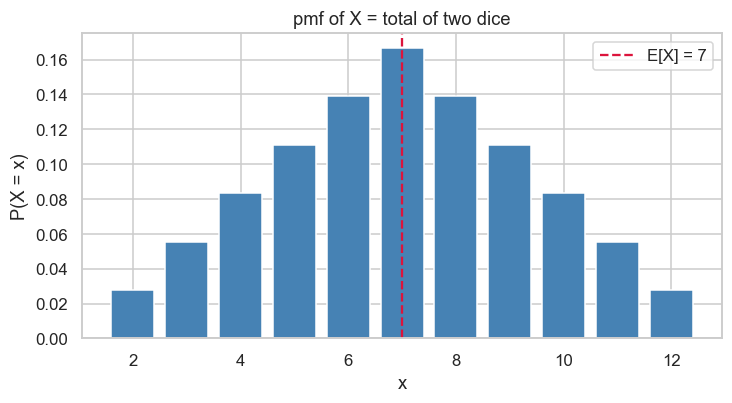

In [49]:
pmf = outcomes["total"].value_counts(normalize=True).sort_index()
x = pmf.index.to_numpy(); p = pmf.to_numpy()

mean = (x * p).sum()                       # E[X]
var = ((x - mean) ** 2 * p).sum()          # Var(X) = E[(X - mu)^2]
print(f"E[X]   = {mean:.2f}")
print(f"Var(X) = {var:.3f}    SD = {np.sqrt(var):.3f}")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(x, p, color="steelblue"); ax.axvline(mean, color="crimson", ls="--", label=f"E[X] = {mean:.0f}")
ax.set_title("pmf of X = total of two dice"); ax.set_xlabel("x"); ax.set_ylabel("P(X = x)"); ax.legend()
plt.show()

> 🎤 SAY: "E[X] is the **long-run average**, not a value you expect to see on any single roll. Here you *can* roll a 7, but for a fair die the expected value 3.5 can never occur."

### Expected value = what the sample average converges to

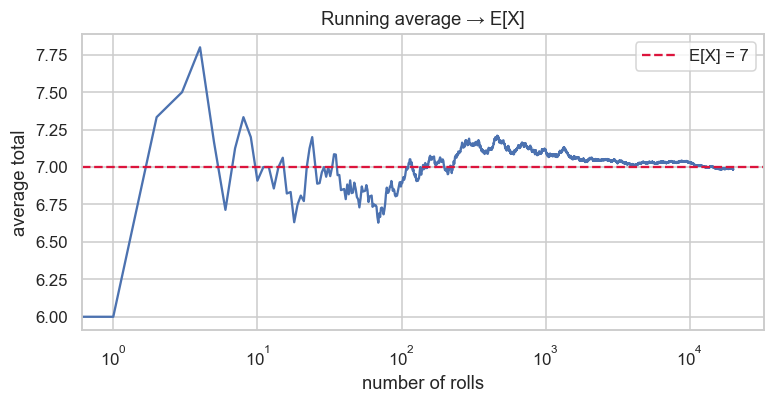

E[2X + 1] = 15.0    Var(2X + 1) = 23.333   (linear transformations: E scales, Var scales by 4)


In [52]:
rolls = rng.integers(1, 7, 20_000) + rng.integers(1, 7, 20_000)
running_mean = np.cumsum(rolls) / np.arange(1, len(rolls) + 1)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(running_mean); ax.axhline(7, color="crimson", ls="--", label="E[X] = 7")
ax.set_xscale("log"); ax.set_xlabel("number of rolls"); ax.set_ylabel("average total"); ax.legend()
ax.set_title("Running average → E[X]")
plt.show()
print("E[2X + 1] =", round(2 * mean + 1, 3), "   Var(2X + 1) =", round(4 * var, 3), "  (linear transformations: E scales, Var scales by 4)")

---
## Part 6 · Probability distributions
A **distribution** is the pmf/pdf pattern a random variable follows. Three workhorses today.

### 6.1 Binomial — number of successes in *n* independent yes/no trials

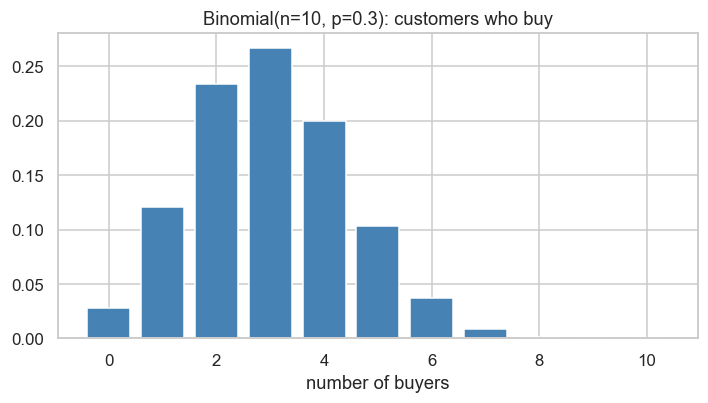

mean = n·p = 3.0    SD = 1.449
P(exactly 3)   = 0.2668
P(at least 5)  = 0.1503   ← 'at least 5' = 1 - P(X ≤ 4)
simulated P(at least 5): 0.1503


In [55]:
n, p = 10, 0.3          # e.g. 10 customers, each buys with probability 0.3
k = np.arange(0, n + 1)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(k, stats.binom.pmf(k, n, p), color="steelblue")
ax.set_title(f"Binomial(n={n}, p={p}): customers who buy"); ax.set_xlabel("number of buyers")
plt.show()
print("mean = n·p =", n * p, "   SD =", round(np.sqrt(n * p * (1 - p)), 3))
print("P(exactly 3)   =", round(stats.binom.pmf(3, n, p), 4))
print("P(at least 5)  =", round(1 - stats.binom.cdf(4, n, p), 4), "  ← 'at least 5' = 1 - P(X ≤ 4)")
print("simulated P(at least 5):", round((rng.binomial(n, p, 200_000) >= 5).mean(), 4))

> ⚠️ Point out the **cdf trap**: `cdf(4)` is P(X ≤ 4), so P(X ≥ 5) = 1 − cdf(**4**), not cdf(5). Off-by-one errors with ≥ / > are a favourite AI mistake — we'll see one in the AI demo.

### 6.2 Poisson — number of events in a fixed time window

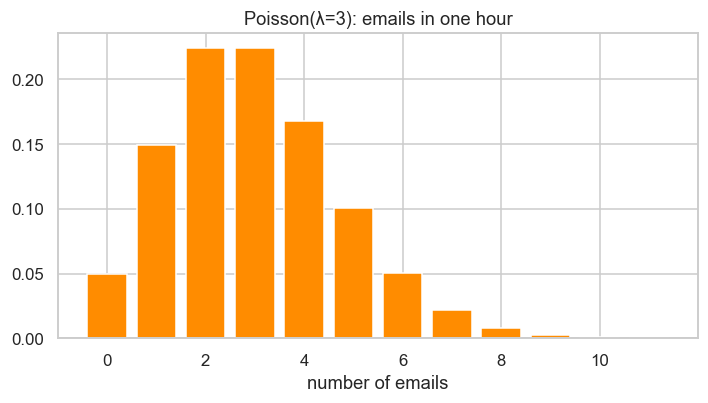

mean = variance = λ = 3
P(no emails in an hour) = 0.0498   (= e^-3)


In [58]:
lam = 3                 # e.g. emails per hour
k = np.arange(0, 12)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.bar(k, stats.poisson.pmf(k, lam), color="darkorange")
ax.set_title(f"Poisson(λ={lam}): emails in one hour"); ax.set_xlabel("number of emails")
plt.show()
print("mean = variance = λ =", lam)
print("P(no emails in an hour) =", round(stats.poisson.pmf(0, lam), 4), "  (= e^-3)")

### 6.3 Normal — the bell curve

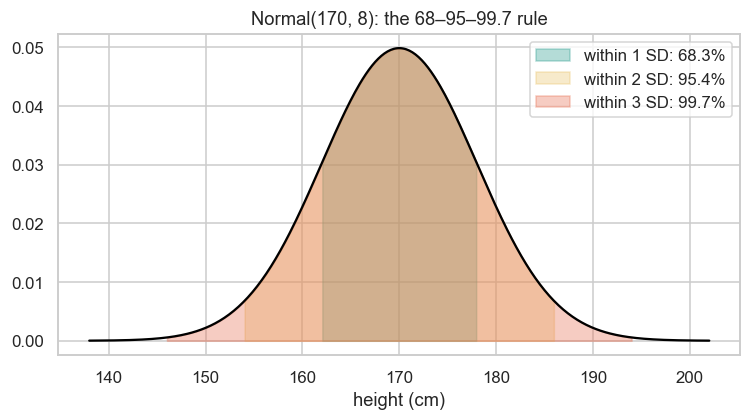

z-score of 185 cm = 1.88   P(height > 185) = 0.0304
the tallest 5% are taller than 183.2 cm   (ppf = inverse of cdf)


In [60]:
mu, sigma = 170, 8       # heights in cm
dist = stats.norm(mu, sigma)
xs = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(xs, dist.pdf(xs), color="black")
for k_, c in zip([1, 2, 3], ["#2a9d8f", "#e9c46a", "#e76f51"]):
    ax.fill_between(xs, dist.pdf(xs), where=(xs > mu - k_ * sigma) & (xs < mu + k_ * sigma), alpha=0.35, color=c,
                    label=f"within {k_} SD: {dist.cdf(mu + k_ * sigma) - dist.cdf(mu - k_ * sigma):.1%}")
ax.set_title("Normal(170, 8): the 68–95–99.7 rule"); ax.set_xlabel("height (cm)"); ax.legend()
plt.show()

z = (185 - mu) / sigma
print(f"z-score of 185 cm = {z:.2f}   P(height > 185) = {1 - dist.cdf(185):.4f}")
print(f"the tallest 5% are taller than {dist.ppf(0.95):.1f} cm   (ppf = inverse of cdf)")

### 6.4 Why the bell curve is everywhere: the Central Limit Theorem

### 🔮 PREDICT (answer in chat *before* running the next cell)


Individual draws from an **Exponential** distribution are very skewed (lots of small values, a long tail).

**What will the histogram of the *average of 30 draws* look like?** A) still skewed &nbsp; B) bell-shaped &nbsp; C) flat

> 🎤 Answer: bell-shaped.

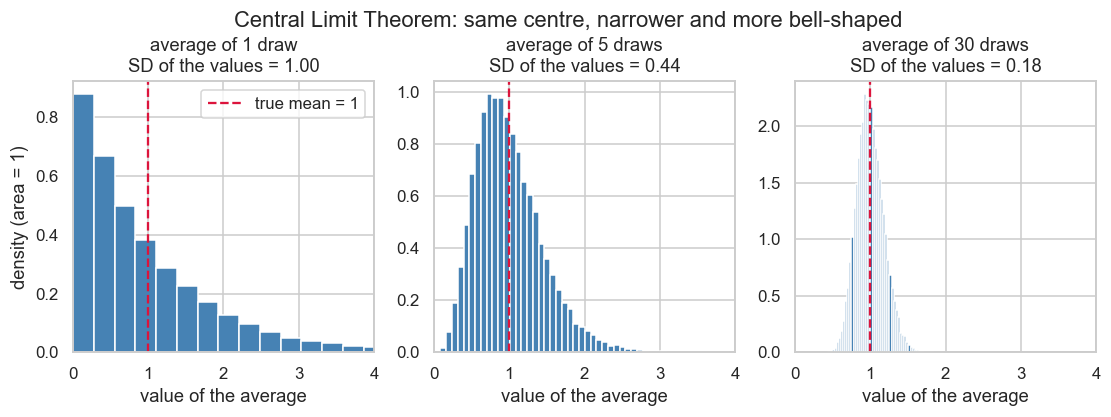

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharex=True)
for ax, size in zip(axes, [1, 5, 30]):
    means = rng.exponential(1.0, size=(20_000, size)).mean(axis=1)
    ax.hist(means, bins=50, color="steelblue", density=True)
    ax.axvline(1, color="crimson", ls="--", label="true mean = 1")
    ax.set_title(f"average of {size} draw{'s' if size > 1 else ''}\nSD of the values = {means.std():.2f}")
    ax.set_xlabel("value of the average")
axes[0].set_ylabel("density (area = 1)")
axes[0].legend()
axes[0].set_xlim(0, 4)
fig.suptitle("Central Limit Theorem: same centre, narrower and more bell-shaped", y=1.08)
plt.show()

> 🎤 SAY: "No matter how weird the original distribution, the **average** of many independent draws is approximately Normal. That's why the bell curve is the default for sample means — and why statistics works."

### 6.5 *Why* it happens: many more ways to reach the middle (dice)

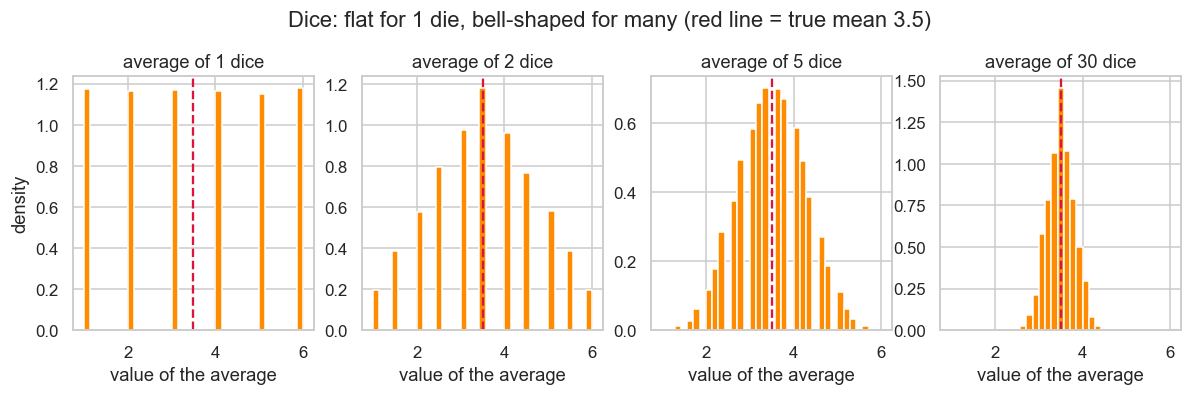

1 dice:     6 equally likely outcomes | ways to get the lowest total: 1 | ways to get the most common total: 1
2 dice:    36 equally likely outcomes | ways to get the lowest total: 1 | ways to get the most common total: 6
3 dice:   216 equally likely outcomes | ways to get the lowest total: 1 | ways to get the most common total: 27
4 dice:  1296 equally likely outcomes | ways to get the lowest total: 1 | ways to get the most common total: 146
5 dice:  7776 equally likely outcomes | ways to get the lowest total: 1 | ways to get the most common total: 780


In [67]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharex=True)
for ax, k in zip(axes, [1, 2, 5, 30]):
    avgs = rng.integers(1, 7, size=(50_000, k)).mean(axis=1)
    ax.hist(avgs, bins=np.linspace(1, 6, 36), color="darkorange", density=True)
    ax.axvline(3.5, color="crimson", ls="--")
    ax.set_title(f"average of {k} dice"); ax.set_xlabel("value of the average")
axes[0].set_ylabel("density")
fig.suptitle("Dice: flat for 1 die, bell-shaped for many (red line = true mean 3.5)", y=1.08)
plt.show()

# how many ways to get the LOWEST total vs the MOST COMMON total?
ways = np.ones(6)
for k in range(1, 6):
    if k > 1:
        ways = np.convolve(ways, np.ones(6))
    print(f"{k} dice: {6**k:>5} equally likely outcomes | ways to get the lowest total: {int(ways[0])} "
          f"| ways to get the most common total: {int(ways.max())}")

> 🎤 SAY: "One die is flat — every value has exactly 1 way. With 5 dice there are 7,776 outcomes: **1** way to get all ones, but **780** ways to get the most common total. That pile-up of ways in the middle IS the bell curve. Averaging cancels ups and downs, so the middle wins."

### Cheat-sheet: which distribution?
| Situation | Distribution | Parameters |
|---|---|---|
| One yes/no trial | Bernoulli | p |
| # successes in *n* independent yes/no trials | **Binomial** | n, p |
| # events in a fixed time/space window | **Poisson** | λ |
| Measurements clustered around a mean | **Normal** | μ, σ |
| Averages of many draws | ≈ Normal (CLT) | |

---
## 🏁 Wrap-up
1. **P(A|B) ≠ P(B|A)** — always say which is which.
2. **Independent ≠ mutually exclusive.**
3. **Bayes: don't forget the base rate.**
4. **If the formula scares you, simulate it.**

➡️ Next: you will learn how to use **AI** to solve probability problems — *and how to catch it when it's wrong.*